In [1]:
!pip install -q kagglehub
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")

In [ ]:
import numpy as np
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("abdullahsherdy/egyptian-sign-language-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'egyptian-sign-language-recognition' dataset.
Path to dataset files: /kaggle/input/egyptian-sign-language-recognition


# **DATA SPLIT**

80% 20%

 the number of videos is different, we will automatically divide by 80% for each Class.

In [ ]:
import os
import random
import math
from collections import defaultdict
# FIX #2 — use the path kagglehub just downloaded instead of a
#           hardcoded Google Drive path that doesn't exist in Colab.
dataset_path = "/root/.cache/kagglehub/datasets/abdullahsherdy/egyptian-sign-language-recognition/versions/1/dataset - rebirth"

train_split = defaultdict(list)
val_split   = defaultdict(list)

classes = sorted(os.listdir(dataset_path))

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    videos = [
        f for f in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, f))
    ]

    random.shuffle(videos)

    split_idx = math.floor(len(videos) * 0.8)

    train_split[cls] = videos[:split_idx]
    val_split[cls]   = videos[split_idx:]

print("Split Summary:")
for cls in classes:
    print(f"  {cls}: Train={len(train_split[cls])}, Val={len(val_split[cls])}")

Split Summary:
  3amel eh: Train=4, Val=2
  3ieb: Train=8, Val=2
  3rabia: Train=8, Val=2
  3waz: Train=8, Val=2
  akhoia: Train=5, Val=2
  alam: Train=4, Val=2
  bhab: Train=7, Val=2
  bkrh: Train=4, Val=2
  bsor3a: Train=8, Val=3
  delwaty: Train=8, Val=3
  docktor: Train=4, Val=2
  efrdha: Train=4, Val=2
  ehtrem nfsk: Train=8, Val=2
  elnhrda: Train=4, Val=1
  ermy wra dhrk: Train=7, Val=2
  fatan: Train=6, Val=2
  fe sark: Train=8, Val=3
  flos: Train=5, Val=2
  fokk many: Train=8, Val=2
  gomma: Train=4, Val=2
  harmy: Train=4, Val=2
  hba hba: Train=6, Val=2
  helw awy: Train=9, Val=3
  hta hta: Train=7, Val=2
  kdab: Train=5, Val=2
  khaif: Train=4, Val=2
  khaly balk: Train=9, Val=3
  khatbty: Train=6, Val=2
  kolya: Train=6, Val=2
  ktab: Train=5, Val=2
  mafish: Train=10, Val=3
  makar: Train=6, Val=2
  manzel: Train=6, Val=2
  mash mashy: Train=8, Val=2
  mashy: Train=8, Val=2
  meraty: Train=4, Val=2
  mohands: Train=6, Val=2
  moshwash: Train=5, Val=2
  msh 3waz: Train=9,

# Frame Extraction

In [ ]:
import cv2

def extract_frames(video_path, output_folder, target_fps=15):
    os.makedirs(output_folder, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS)

    if original_fps == 0:        # some files don't report fps; assume 30
        original_fps = 30

    frame_interval = max(int(original_fps / target_fps), 1)

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_interval == 0:
            frame_name = f"frame_{saved_count:04d}.jpg"
            cv2.imwrite(os.path.join(output_folder, frame_name), frame)
            saved_count += 1

        frame_count += 1

    cap.release()
    return saved_count

In [ ]:
metadata = []

for split_name, split_dict in [("train", train_split), ("val", val_split)]:
    for cls in split_dict:
        for video_name in split_dict[cls]:

            video_path    = os.path.join(dataset_path, cls, video_name)
            video_id      = video_name.split('.')[0]
            output_folder = f"/content/frames/{split_name}/{cls}/{video_id}"  # FIX #4

            num_frames = extract_frames(video_path, output_folder)

            metadata.append({
                "video_id":   video_id,
                "class":      cls,
                "num_frames": num_frames,
                "split":      split_name
            })



# Save Metadata

In [ ]:
import pandas as pd

df = pd.DataFrame(metadata)
df.to_csv("/content/metadata.csv", index=False)

print(df)

          video_id     class  num_frames  split
0    3amel eh_6506  3amel eh          52  train
1    3amel eh_7466  3amel eh          67  train
2    3amel eh_7854  3amel eh          48  train
3    3amel eh_8593  3amel eh          47  train
4        3ieb_7829      3ieb          31  train
..             ...       ...         ...    ...
472   yallhwy_2772   yallhwy          35    val
473   yallhwy_1122   yallhwy          33    val
474   yallhwy_1640   yallhwy          38    val
475     yshtm_1044     yshtm          25    val
476     yshtm_3434     yshtm          24    val

[477 rows x 4 columns]


In [ ]:

# ============================================================
# STEP 5 — LOAD FRAMES INTO MEMORY
# ============================================================
# Builds video_frames dict:  video_id → sorted list of .jpg paths
# Prints a warning for any video whose folder is missing (e.g.
# extraction failed or the CSV was loaded from a previous run).

metadata_path    = "/content/metadata.csv"
frames_base_path = "/content/frames"

df = pd.read_csv(metadata_path)

video_frames        = {}
total_frames_loaded = 0

for _, row in df.iterrows():
    video_id = row["video_id"]
    split    = row["split"]
    cls      = row["class"]

    video_folder = os.path.join(frames_base_path, split, cls, video_id)

    if not os.path.exists(video_folder):
        print(f"Folder not found: {video_folder}")
        continue

    frames = sorted([
        os.path.join(video_folder, f)
        for f in os.listdir(video_folder)
        if f.endswith(".jpg")
    ])

    video_frames[video_id]  = frames
    total_frames_loaded    += len(frames)

print("=================================")
print(f"Loaded frames for {len(video_frames)} videos")
print(f"Total frames loaded: {total_frames_loaded}")
print("=================================")

Loaded frames for 477 videos
Total frames loaded: 17988


In [ ]:
# ============================================================
# STEP 6 — INSTALL MEDIAPIPE
# ============================================================
# MediaPipe 0.10.20 is pinned because the `solutions` API
# (mp.solutions.holistic) was deprecated / removed in later
# versions.  After the install Colab will ask you to restart
# the runtime — do so, then continue from STEP 7 onward.
# You do NOT need to re-run Steps 0-5 after the restart.

!pip uninstall -y mediapipe
!pip install mediapipe==0.10.20

import mediapipe as mp
print(mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))


Found existing installation: mediapipe 0.10.20
Uninstalling mediapipe-0.10.20:
  Successfully uninstalled mediapipe-0.10.20
  Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl (35.6 MB)


0.10.20
Has solutions: True


In [ ]:
# ============================================================
# STEP 7 — EXTRACT LANDMARKS WITH MEDIAPIPE HOLISTIC
# ============================================================
# MediaPipe Holistic runs a combined model that detects:
#   • left hand  — 21 landmarks × (x, y, z) = 63 values
#   • right hand — 21 landmarks × (x, y, z) = 63 values
#   • face mesh  — we keep only 10 key points  = 30 values
# Total per frame: 156 floats
#
# x, y are normalised to [0, 1] relative to the image size.
# z is depth relative to the wrist (hands) or nose (face).
# If a hand or face is not detected, we fill zeros.
#
# FACE_IDX — the 10 face landmarks we keep:
#   0=nose tip, 1=between brows, 13/14=lips, 17=chin,
#   33/263=eye corners, 61/291=mouth corners, 199=chin tip

import mediapipe as mp
import cv2
import numpy as np

mp_holistic = mp.solutions.holistic

FACE_IDX   = [1, 33, 61, 199, 263, 291, 17, 0, 13, 14]
all_features     = []   # one entry per frame (not per video)
all_features_raw = {}   # video_id → list of raw (unnormalised) feature vectors
                        # kept separately so we can visualise correctly (FIX #6)

# Process all videos
# with mp_holistic.Holistic(static_image_mode=True) as holistic:
#     for video_id, frames in video_frames.items():
#         print("Processing video:", video_id)
#         raw_for_video = []


# change 1 to any number N, or remove [:1] entirely to process all videos

videos_to_process = dict(list(video_frames.items()))

with mp_holistic.Holistic(static_image_mode=True) as holistic:
    for video_id, frames in videos_to_process.items():
        print("Processing video:", video_id)
        raw_for_video = []

        for frame_path in frames:
            image     = cv2.imread(frame_path)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            results   = holistic.process(image_rgb)

            features = []

            if results.left_hand_landmarks:
                for lm in results.left_hand_landmarks.landmark:
                    features.extend([lm.x, lm.y, lm.z])
            else:
                features.extend([0] * 63)

            if results.right_hand_landmarks:
                for lm in results.right_hand_landmarks.landmark:
                    features.extend([lm.x, lm.y, lm.z])
            else:
                features.extend([0] * 63)

            if results.face_landmarks:
                for idx in FACE_IDX:
                    lm = results.face_landmarks.landmark[idx]
                    features.extend([lm.x, lm.y, lm.z])
            else:
                features.extend([0] * (len(FACE_IDX) * 3))

            all_features.append(features)
            raw_for_video.append(features[:])

        all_features_raw[video_id] = raw_for_video

print("Total frames processed:", len(all_features))
print("Feature length per frame:", len(all_features[0]))

all_features_np = np.array(all_features)



Processing video: 3amel eh_6506
Processing video: 3amel eh_7466
Processing video: 3amel eh_7854
Processing video: 3amel eh_8593
Processing video: 3ieb_7829
Processing video: 3ieb_4781
Processing video: 3ieb_4767
Processing video: 3ieb_9195
Processing video: 3ieb_1491
Processing video: 3ieb_5837
Processing video: 3ieb_6666
Processing video: 3ieb_2276
Processing video: 3rabia_1853
Processing video: 3rabia_6380
Processing video: 3rabia_8922
Processing video: 3rabia_5597
Processing video: 3rabia_3806
Processing video: 3rabia_5319
Processing video: 3rabia_3183
Processing video: 3rabia_2138
Processing video: 3waz_6111
Processing video: 3waz_1923
Processing video: 3waz_7674
Processing video: 3waz_9676
Processing video: 3waz_2553
Processing video: 3waz_7274
Processing video: 3waz_7879
Processing video: 3waz_9342
Processing video: akhoia_4281
Processing video: akhoia_8789
Processing video: akhoia_9605
Processing video: akhoia_9368
Processing video: akhoia_1389
Processing video: alam_6271
Proces

In [ ]:
# ============================================================
# STEP 8 — NORMALISE LANDMARKS
# ============================================================
# Why normalise?
#   Raw x/y coords depend on where the signer sat in the frame.
#   We want the model to learn the *shape* of the gesture, not
#   its position or how big the hand appears in the camera.
#
# How:
#   • Translation: subtract the wrist point (point 0) from each
#     hand so all hands are centred at the origin.
#     For the face subset, subtract the centroid.
#   • Scale: divide by the bounding-box diagonal so a close-up
#     hand and a far-away hand end up the same size.
#   • Zero-filled landmarks (not detected) are left as zeros so
#     the mod

def normalize_frame(frame_feat):
    # frame_feat: numpy array shape (156,)
    left_hand  = frame_feat[0:63].reshape(21, 3).copy()
    right_hand = frame_feat[63:126].reshape(21, 3).copy()
    face       = frame_feat[126:].reshape(-1, 3).copy()

    # ── Translation ──────────────────────────────────────────
    left_origin  = left_hand[0]  if left_hand.any()  else np.zeros(3)
    right_origin = right_hand[0] if right_hand.any() else np.zeros(3)
    face_center  = face.mean(axis=0) if face.any()   else np.zeros(3)

    left_hand  -= left_origin
    right_hand -= right_origin
    face       -= face_center

    # ── Scale ────────────────────────────────────────────────
    left_scale  = np.linalg.norm(left_hand.max(axis=0)  - left_hand.min(axis=0))
    right_scale = np.linalg.norm(right_hand.max(axis=0) - right_hand.min(axis=0))
    face_scale  = np.linalg.norm(face.max(axis=0)       - face.min(axis=0))

    left_scale  = left_scale  if left_scale  != 0 else 1
    right_scale = right_scale if right_scale != 0 else 1
    face_scale  = face_scale  if face_scale  != 0 else 1

    left_hand  /= left_scale
    right_hand /= right_scale
    face       /= face_scale

    return np.concatenate([left_hand.flatten(),
                           right_hand.flatten(),
                           face.flatten()])

normalized_features = np.array([normalize_frame(f) for f in all_features_np])
print("Normalized features shape:", normalized_features.shape)   # (total_frames, 156)


Normalized features shape: (17988, 156)


In [ ]:
# ============================================================
# STEP 9 — SAVE PER-VIDEO .npy ARRAYS
# ============================================================
# all_features / normalized_features are one big flat array over
# ALL frames from ALL videos.  We slice them back into per-video
# chunks and save each as landmarks/<video_id>.npy
# Shape of each file: (num_frames_in_video, 156)

os.makedirs("/content/landmarks", exist_ok=True)

video_ids = list(video_frames.keys())
start_idx = 0

for vid in video_ids:
    num_frames = len(video_frames[vid])
    end_idx    = start_idx + num_frames

    vid_array = normalized_features[start_idx:end_idx]
    np.save(f"/content/landmarks/{vid}.npy", vid_array)

    start_idx = end_idx

# Quick sanity check — print shape of every saved file
for file in sorted(os.listdir("/content/landmarks")):
    if file.endswith(".npy"):
        arr = np.load(f"/content/landmarks/{file}")
        print(f"{file}: {arr.shape}")



3amel eh_5006.npy: (39, 156)
3amel eh_6506.npy: (52, 156)
3amel eh_7466.npy: (67, 156)
3amel eh_7854.npy: (48, 156)
3amel eh_7885.npy: (47, 156)
3amel eh_8593.npy: (47, 156)
3ieb_1491.npy: (35, 156)
3ieb_2185.npy: (32, 156)
3ieb_2276.npy: (34, 156)
3ieb_2960.npy: (38, 156)
3ieb_4767.npy: (35, 156)
3ieb_4781.npy: (41, 156)
3ieb_5837.npy: (31, 156)
3ieb_6666.npy: (36, 156)
3ieb_7829.npy: (31, 156)
3ieb_9195.npy: (36, 156)
3rabia_1853.npy: (40, 156)
3rabia_2138.npy: (58, 156)
3rabia_2928.npy: (35, 156)
3rabia_3183.npy: (28, 156)
3rabia_3806.npy: (52, 156)
3rabia_5319.npy: (49, 156)
3rabia_5597.npy: (36, 156)
3rabia_5951.npy: (42, 156)
3rabia_6380.npy: (36, 156)
3rabia_8922.npy: (56, 156)
3waz_1923.npy: (38, 156)
3waz_2209.npy: (38, 156)
3waz_2553.npy: (34, 156)
3waz_4076.npy: (36, 156)
3waz_6111.npy: (39, 156)
3waz_7274.npy: (36, 156)
3waz_7674.npy: (30, 156)
3waz_7879.npy: (29, 156)
3waz_9342.npy: (41, 156)
3waz_9676.npy: (34, 156)
akhoia_1389.npy: (34, 156)
akhoia_4281.npy: (34, 156)
ak

Video: 3amel eh_6506
Total frames: 52
Raw landmarks shape: (52, 156)


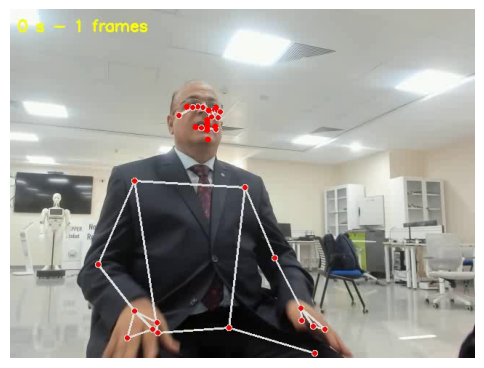

Frames with no detection: [39]


In [ ]:
# ============================================================
# STEP 10 — VISUALISE: landmarks on a single frame
# ============================================================
# FIX #5 — `frame_idx =` was left blank (SyntaxError).
#           Set it to 0 to look at the first frame.
#           Change it to any index you like.
#
# FIX #6 — The original code passed *normalised* landmarks to
#   plot_landmarks_on_frame() and then did `int(x * image_width)`
#   to convert to pixel coords.  After normalisation x/y are
#   centred on 0 and can be negative or > 1, so those dots
#   appear in the wrong place or crash with out-of-bounds coords.
#   Fix: load the RAW (pre-normalisation) landmarks from
#   all_features_raw for visualisation purposes.

import os
import numpy as np
import cv2
from matplotlib import pyplot as plt

frames_base_path = "/content/frames"
landmarks_path   = "/content/landmarks"

# Pick the first video as a test
video_id    = list(video_frames.keys())[0]
frame_files = sorted(video_frames[video_id])

print(f"Video: {video_id}")
print(f"Total frames: {len(frame_files)}")

# Load RAW landmarks for this video (FIX #6)
raw_landmarks_video = np.array(all_features_raw[video_id])
print(f"Raw landmarks shape: {raw_landmarks_video.shape}")


def plot_landmarks_on_frame(frame_path, landmarks):
    """
    Overlay hand + face landmark dots on a frame.
    `landmarks` must be RAW (not normalised) so that x, y are
    in [0, 1] relative to the image dimensions.
    """
    img = cv2.imread(frame_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    left_hand   = landmarks[:63].reshape(-1, 3)
    right_hand  = landmarks[63:126].reshape(-1, 3)
    face_points = landmarks[126:].reshape(-1, 3)

    for pts in [left_hand, right_hand, face_points]:
        for x, y, z in pts:
            if x == 0 and y == 0:   # skip undetected points
                continue
            px = int(np.clip(x * w, 0, w - 1))
            py = int(np.clip(y * h, 0, h - 1))
            cv2.circle(img, (px, py), 4, (255, 0, 0), -1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


frame_idx = 0   # FIX #5 — was blank, causing SyntaxError; change to any valid index
plot_landmarks_on_frame(frame_files[frame_idx], raw_landmarks_video[frame_idx])

# Check which frames had zero detections (hand not visible in frame)
failed_frames = [i for i, lm in enumerate(raw_landmarks_video) if np.sum(lm) == 0]
print(f"Frames with no detection: {failed_frames}")


In [ ]:
# ============================================================
# STEP 11 — FILTER OUTLIER LANDMARKS
# ============================================================
# Sometimes MediaPipe returns a landmark point that is spatially
# far outside the main hand cluster (a false detection).
# filter_outside_points() removes any point whose (x, y) falls
# outside threshold × bounding-box of the other points.
# Applied here only to the first video as a demonstration.

def filter_outside_points(landmarks, threshold=1.2):
    filtered = landmarks.copy()

    def _filter_segment(seg, offset):
        if not np.any(seg):
            return
        min_xy  = seg[:, :2].min(axis=0)
        max_xy  = seg[:, :2].max(axis=0)
        center  = (min_xy + max_xy) / 2
        size    = (max_xy - min_xy) * threshold
        for i, (x, y, z) in enumerate(seg):
            if (x < center[0] - size[0] / 2 or x > center[0] + size[0] / 2
                    or y < center[1] - size[1] / 2 or y > center[1] + size[1] / 2):
                filtered[offset + i * 3 : offset + i * 3 + 3] = 0

    _filter_segment(landmarks[0:63].reshape(21, 3),   0)
    _filter_segment(landmarks[63:126].reshape(21, 3), 63)
    _filter_segment(landmarks[126:].reshape(-1, 3),  126)
    return filtered


first_video_id = list(video_frames.keys())[0]
num_frames_first = len(video_frames[first_video_id])

# Slice the normalised array for just this video
first_video_features = normalized_features[0:num_frames_first]
first_video_features_filtered = np.array([
    filter_outside_points(f) for f in first_video_features
])

print("Original shape:", first_video_features.shape)
print("Filtered shape:", first_video_features_filtered.shape)



Original shape: (52, 156)
Filtered shape: (52, 156)


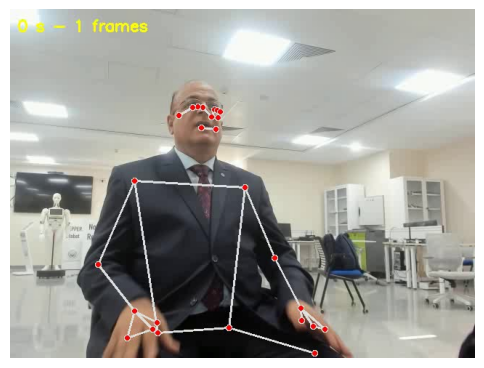

In [ ]:
# ============================================================
# STEP 12 — ANIMATE FILTERED LANDMARKS
# ============================================================
# Plays back the first video as a matplotlib animation with
# landmark dots overlaid.  Uses the FILTERED normalised coords
# — these are centred/scaled, so we map them back to pixel
# space by re-adding 0.5 (rough centre) × image dimensions.
# This is just a visualisation sanity-check, not training data.

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

first_video_id         = list(video_frames.keys())[0]
frame_files            = sorted(video_frames[first_video_id])
video_landmarks_filtered = first_video_features_filtered

fig, ax = plt.subplots(figsize=(6, 6))
img_display = ax.imshow(cv2.cvtColor(cv2.imread(frame_files[0]), cv2.COLOR_BGR2RGB))
scat = ax.scatter([], [], c="r", s=20)
ax.axis("off")

def update(frame_idx):
    img = cv2.imread(frame_files[frame_idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_display.set_data(img)

    landmarks = video_landmarks_filtered[frame_idx]
    points    = []

    for pts in [landmarks[:63].reshape(-1, 3),
                landmarks[63:126].reshape(-1, 3),
                landmarks[126:].reshape(-1, 3)]:
        for x, y, z in pts:
            if not (x == 0 and y == 0 and z == 0):
                # normalised coords are centred on 0 → shift by +0.5 to
                # get approximate pixel fraction, then scale to image size
                points.append([(x + 0.5) * img.shape[1],
                               (y + 0.5) * img.shape[0]])

    if points:
        scat.set_offsets(np.array(points))
    else:
        scat.set_offsets(np.empty((0, 2)))

ani = FuncAnimation(fig, update, frames=len(frame_files), interval=50)
plt.show()


In [ ]:
import numpy as np
import os

landmarks_path = "/content/landmarks"
N_FRAMES = 20  # fixed sequence length for LSTM

X_mlp  = []  # (num_videos, 156)      — for MLP
X_lstm = []  # (num_videos, 20, 156)  — for LSTM
y      = []  # labels

# Build label index from filenames
# filename format: <class_name>_<video_id>.npy
label_set = sorted(set(
    "_".join(f.replace(".npy", "").split("_")[:-1])
    for f in os.listdir(landmarks_path)
    if f.endswith(".npy")
))
label2idx = {label: i for i, label in enumerate(label_set)}

print(f"Number of classes: {len(label_set)}")
print("Examples:", label_set[:5])

for f in sorted(os.listdir(landmarks_path)):
    if not f.endswith(".npy"):
        continue

    data = np.load(os.path.join(landmarks_path, f))

    # Skip empty files
    if data.shape[0] == 0:
        continue

    # Extract label from filename
    label = "_".join(f.replace(".npy", "").split("_")[:-1])
    if label not in label2idx:
        continue

    # ── MLP feature: average 5 center frames ──
    # We sample frames around the middle of the video to capture
    # the most representative pose, then average them into one vector
    num_frames = data.shape[0]
    center  = num_frames // 2
    indices = range(max(0, center - 2), min(num_frames, center + 3))
    mlp_feature = data[list(indices)].mean(axis=0)
    X_mlp.append(mlp_feature)

    # ── LSTM feature: pad or trim to N_FRAMES ──
    # All sequences must be the same length for batch training.
    # If video is longer than N_FRAMES → trim from the start.
    # If video is shorter           → pad with zeros at the end.
    if num_frames >= N_FRAMES:
        lstm_feature = data[:N_FRAMES]
    else:
        pad = np.zeros((N_FRAMES - num_frames, 156))
        lstm_feature = np.vstack([data, pad])
    X_lstm.append(lstm_feature)

    y.append(label2idx[label])

# Convert to numpy arrays
X_mlp  = np.array(X_mlp)
X_lstm = np.array(X_lstm)
y      = np.array(y)

print(f"\n X_mlp shape:  {X_mlp.shape}")   # (476, 156)
print(f" X_lstm shape: {X_lstm.shape}")    # (476, 20, 156)
print(f" y shape:      {y.shape}")         # (476,)

# Save features and label mapping to disk
np.save("/content/X_mlp.npy",  X_mlp)
np.save("/content/X_lstm.npy", X_lstm)
np.save("/content/y.npy",      y)
np.save("/content/label2idx.npy", label2idx)

print("\n All arrays saved!")

Number of classes: 56
Examples: ['3amel eh', '3ieb', '3rabia', '3waz', 'akhoia']

 X_mlp shape:  (476, 156)
 X_lstm shape: (476, 20, 156)
 y shape:      (476,)

 All arrays saved!


## MLP TRINING

In [ ]:
# ============================================================
# STEP 6 — TRAIN MLP CLASSIFIER
# ============================================================
# We train a small Multi-Layer Perceptron (MLP) on the
# aggregated landmark features extracted in Step 5.
#
# Architecture:
#   Input  → Dense(64, ReLU) → Dropout(0.2)
#            → Dense(32, ReLU) → Dense(num_classes, Softmax)
#
# We use EarlyStopping to avoid overfitting and save the best
# model weights based on validation accuracy.
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
import os

# ── Load features ──────────────────────────────────────────
X = np.load("/content/X_mlp.npy")
y = np.load("/content/y.npy")

num_classes = len(np.unique(y))
input_dim   = X.shape[1]

print(f"Input dim:   {input_dim}")
print(f"Num classes: {num_classes}")
print(f"Dataset size: {X.shape[0]} samples")

# ── Train / Validation split ───────────────────────────────
# Split at video level (already done in Step 5),
# so we just do a random 80/20 split here.
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keep class distribution balanced
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Val size:   {X_val.shape[0]}")

# ── Build MLP model ────────────────────────────────────────
model = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
], name="mlp_sign_classifier")

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────
os.makedirs("/content/artifacts", exist_ok=True)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,          # stop if no improvement for 10 epochs
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="/content/artifacts/model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# ── Train ──────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# ── Evaluate ───────────────────────────────────────────────
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n Best Val Accuracy: {val_acc:.4f}")
print(f" Model saved to:   /content/artifacts/model.h5")

Input dim:   156
Num classes: 56
Dataset size: 476 samples

Train size: 380
Val size:   96


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "mlp_sign_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        10,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 56)             │         1,848 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,976 (54.59 KB)

...


Epoch 27: finished saving model to /content/artifacts/model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5684 - loss: 1.4598 - val_accuracy: 0.5417 - val_loss: 2.0623
Epoch 28/100
16/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6301 - loss: 1.4002 
Epoch 28: val_accuracy did not improve from 0.54167
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5816 - loss: 1.4396 - val_accuracy: 0.5000 - val_loss: 2.0634
Epoch 29/100
17/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5956 - loss: 1.3857 
Epoch 29: val_accuracy did not improve from 0.54167
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6079 - loss: 1.3776 - val_accuracy: 0.5208 - val_loss: 2.0429
Epoch 30/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6014 - loss: 1.3828
Epoch 30: val_accuracy did not improve from 0.54167
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5895 - loss: 1.4003 - val_accuracy: 0.5208 - val_loss: 2.0229
Epoch 31/100
15/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accur


Epoch 31: finished saving model to /content/artifacts/model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6132 - loss: 1.3306 - val_accuracy: 0.5521 - val_loss: 2.0141
Epoch 32/100
14/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6143 - loss: 1.2852 
Epoch 32: val_accuracy improved from 0.55208 to 0.56250, saving model to /content/artifacts/model.h5



Epoch 32: finished saving model to /content/artifacts/model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6132 - loss: 1.2947 - val_accuracy: 0.5625 - val_loss: 1.9964
Epoch 33/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6497 - loss: 1.2677
Epoch 33: val_accuracy did not improve from 0.56250
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6158 - loss: 1.2821 - val_accuracy: 0.5625 - val_loss: 1.9978
Epoch 34/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5501 - loss: 1.3273
Epoch 34: val_accuracy improved from 0.56250 to 0.58333, saving model to /content/artifacts/model.h5



Epoch 34: finished saving model to /content/artifacts/model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5947 - loss: 1.2705 - val_accuracy: 0.5833 - val_loss: 1.9839
Epoch 35/100
22/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6133 - loss: 1.3167
Epoch 35: val_accuracy did not improve from 0.58333
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6289 - loss: 1.2540 - val_accuracy: 0.5833 - val_loss: 1.9644
Epoch 36/100
17/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5875 - loss: 1.4036
Epoch 36: val_accuracy did not improve from 0.58333
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6237 - loss: 1.2560 - val_accuracy: 0.5729 - val_loss: 1.9648
Epoch 37/100
17/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6332 - loss: 1.1857
Epoch 37: val_accuracy did not improve from 0.58333
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6079 - loss: 1.2444 - val_accuracy: 0.5417 - val_loss: 1.9610
Epoch 38/100
16/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ac


Epoch 39: finished saving model to /content/artifacts/model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6263 - loss: 1.1980 - val_accuracy: 0.6146 - val_loss: 1.9251
Epoch 40/100
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6550 - loss: 1.0623 
Epoch 40: val_accuracy did not improve from 0.61458
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6526 - loss: 1.1681 - val_accuracy: 0.5833 - val_loss: 1.9284
Epoch 41/100
18/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6401 - loss: 1.1659 
Epoch 41: val_accuracy did not improve from 0.61458
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6737 - loss: 1.1443 - val_accuracy: 0.5729 - val_loss: 1.9369
Epoch 42/100
18/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5981 - loss: 1.2505 
Epoch 42: val_accuracy did not improve from 0.61458
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6658 - loss: 1.1255 - val_accuracy: 0.6146 - val_loss: 1.9126
Epoch 43/100
18/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accur

In [ ]:
# ============================================================
# STEP 6 PART 2 — IMPROVED MLP (128 → 64 → 32)
# ============================================================
# Wider layers give the model more capacity to learn
# the differences between 56 classes.
# We also add BatchNormalization to stabilize training
# and help the model converge faster.
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

# ── Load features ──────────────────────────────────────────
X = np.load("/content/X_mlp.npy")
y = np.load("/content/y.npy")

num_classes = len(np.unique(y))
input_dim   = X.shape[1]

# ── Train / Validation split ───────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ── Build improved MLP ─────────────────────────────────────
model = Sequential([
    Input(shape=(input_dim,)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(num_classes, activation="softmax")
], name="mlp_improved")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ── Callbacks ──────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=15,              # more patience than before
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="/content/artifacts/model_improved.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# ── Train ──────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,               # more epochs to allow convergence
    batch_size=16,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# ── Evaluate ───────────────────────────────────────────────
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n Best Val Accuracy: {val_acc:.4f}")
print(f" Model saved to:   /content/artifacts/model_improved.keras")

Model: "mlp_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        20,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 56)             │         1,848 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,048 (129.09 KB)

 Trainable params: 32,664 (127.59 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/150
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0085 - loss: 4.4547
Epoch 1: val_accuracy improved from None to 0.04167, saving model to /content/artifacts/model_improved.keras

Epoch 1: finished saving model to /content/artifacts/model_improved.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.0158 - loss: 4.3977 - val_accuracy: 0.0417 - val_loss: 3.9994
Epoch 2/150
17/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0409 - loss: 4.0067
Epoch 2: val_accuracy did not improve from 0.04167
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0395 - loss: 3.9520 - val_accuracy: 0.0312 - val_loss: 3.9821
Epoch 3/150
21/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0767 - loss: 3.8103
Epoch 3: val_accuracy improved from 0.04167 to 0.08333, saving model to /content/artifacts/model_improved.keras

Epoch 3: finished saving model to /content/artifacts/model_improved.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0789 - loss: 3.8075 - val_accuracy: 0

In [ ]:
# ============================================================
# STEP 7 — INFERENCE WRAPPER (with Temporal Smoothing)
# ============================================================

import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
from collections import deque, Counter

# ── Constants ──────────────────────────────────────────────
MODEL_PATH     = "/content/artifacts/model_improved.keras"
LABEL2IDX_PATH = "/content/label2idx.npy"
FACE_IDX       = [1, 33, 61, 199, 263, 291, 17, 0, 13, 14]

# ── MediaPipe setup ────────────────────────────────────────
mp_holistic = mp.solutions.holistic

# ── Load model & labels ────────────────────────────────────
def load_model():
    model     = tf.keras.models.load_model(MODEL_PATH)
    label2idx = np.load(LABEL2IDX_PATH, allow_pickle=True).item()
    idx2label = {v: k for k, v in label2idx.items()}
    print(f"✅ Model loaded — {len(idx2label)} classes")
    return model, idx2label

# ── Extract landmarks ──────────────────────────────────────
def extract_landmarks(frame, holistic):
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results   = holistic.process(image_rgb)
    features  = []

    if results.left_hand_landmarks:
        for lm in results.left_hand_landmarks.landmark:
            features.extend([lm.x, lm.y, lm.z])
    else:
        features.extend([0] * 63)

    if results.right_hand_landmarks:
        for lm in results.right_hand_landmarks.landmark:
            features.extend([lm.x, lm.y, lm.z])
    else:
        features.extend([0] * 63)

    if results.face_landmarks:
        for idx in FACE_IDX:
            lm = results.face_landmarks.landmark[idx]
            features.extend([lm.x, lm.y, lm.z])
    else:
        features.extend([0] * 30)

    return np.array(features, dtype=np.float32)

# ── Normalize landmarks ────────────────────────────────────
def normalize_frame(frame_feat):
    left_hand  = frame_feat[0:63].reshape(21, 3).copy()
    right_hand = frame_feat[63:126].reshape(21, 3).copy()
    face       = frame_feat[126:].reshape(-1, 3).copy()

    left_origin  = left_hand[0]  if left_hand.any()  else np.zeros(3)
    right_origin = right_hand[0] if right_hand.any() else np.zeros(3)
    face_center  = face.mean(axis=0) if face.any()   else np.zeros(3)

    left_hand  -= left_origin
    right_hand -= right_origin
    face       -= face_center

    left_scale  = np.linalg.norm(left_hand.max(axis=0)  - left_hand.min(axis=0))
    right_scale = np.linalg.norm(right_hand.max(axis=0) - right_hand.min(axis=0))
    face_scale  = np.linalg.norm(face.max(axis=0)       - face.min(axis=0))

    left_hand  /= left_scale  if left_scale  != 0 else 1
    right_hand /= right_scale if right_scale != 0 else 1
    face       /= face_scale  if face_scale  != 0 else 1

    return np.concatenate([left_hand.flatten(),
                           right_hand.flatten(),
                           face.flatten()])

# ── Predict single frame ───────────────────────────────────
def predict_frame(frame, model, idx2label, holistic):
    raw = extract_landmarks(frame, holistic)

    if raw[:126].sum() == 0:
        return "No hands detected", 0.0

    norm = normalize_frame(raw)
    inp  = norm.reshape(1, -1)

    probs      = model.predict(inp, verbose=0)[0]
    class_idx  = np.argmax(probs)
    confidence = probs[class_idx]
    label      = idx2label[class_idx]

    return label, float(confidence)


# ── Temporal Smoother (النسخة المصححة) ────────────────────
class PredictionSmoother:
    def __init__(self, window=20, threshold=0.4):  # ← window كبرناه، threshold خفضناه
        self.window    = deque(maxlen=window)
        self.threshold = threshold

    def update(self, label):
        if label != "No hands detected":
            self.window.append(label)

    def predict(self):
        if len(self.window) < 5:              # ← من 3 لـ 5 عشان يكون أكثر استقراراً
            return "Waiting...", 0.0

        counts    = Counter(self.window)
        top_label = counts.most_common(1)[0][0]
        top_ratio = counts[top_label] / len(self.window)

        if top_ratio >= self.threshold:
            return top_label, top_ratio

        return "Uncertain", 0.0

    def reset(self):
        self.window.clear()


# ── Sanity Check
model, idx2label = load_model()
smoother         = PredictionSmoother(window=20, threshold=0.4)

sample_video_id  = list(video_frames.keys())[0]
true_label       = sample_video_id.rsplit('_', 1)[0]

print(f"\n🎯 True label : {true_label}")
print(f"Total frames: {len(video_frames[sample_video_id])}")
print("\n── Frame-by-frame (with smoothing) ─────────────────")

with mp_holistic.Holistic(
    static_image_mode=True,
    min_detection_confidence=0.3,
    min_tracking_confidence=0.3
) as holistic:

    for i in range(min(30, len(video_frames[sample_video_id]))):  # ← من 20 لـ 30 frame
        frame_path = video_frames[sample_video_id][i]
        frame      = cv2.imread(frame_path)

        if frame is None:
            print(f"  Frame {i:02d} → Failed to read")
            continue

        raw_label, raw_conf        = predict_frame(frame, model, idx2label, holistic)
        smoother.update(raw_label)
        stable_label, stable_ratio = smoother.predict()

        print(f"  Frame {i:02d} │ raw: {raw_label:<22} │ stable: {stable_label:<22} ({stable_ratio:.0%})")

print("\n── Final Result ─────────────────────────────────────")
print(f"  Stable prediction : {stable_label}")
print(f"  Confidence        : {stable_ratio:.0%}")
print(f"  True label        : {true_label}")
print(f"  Match             : {'✅ Correct' if stable_label == true_label else ' Wrong'}")

✅ Model loaded — 56 classes

🎯 True label : 3amel eh
Total frames: 52

── Frame-by-frame (with smoothing) ─────────────────
  Frame 00 │ raw: No hands detected      │ stable: Waiting...             (0%)
  Frame 01 │ raw: No hands detected      │ stable: Waiting...             (0%)
  Frame 02 │ raw: No hands detected      │ stable: Waiting...             (0%)
  Frame 03 │ raw: No hands detected      │ stable: Waiting...             (0%)
  Frame 04 │ raw: ehtrem nfsk            │ stable: Waiting...             (0%)
  Frame 05 │ raw: ehtrem nfsk            │ stable: Waiting...             (0%)
  Frame 06 │ raw: ehtrem nfsk            │ stable: Waiting...             (0%)
  Frame 07 │ raw: oda                    │ stable: Waiting...             (0%)
  Frame 08 │ raw: mohands                │ stable: ehtrem nfsk            (60%)
  Frame 09 │ raw: No hands detected      │ stable: ehtrem nfsk            (60%)
  Frame 10 │ raw: sadak                  │ stable: ehtrem nfsk            (50%)
  Fr